# Train XGBoost Churn Classifier

Trains XGBoost on synthetic deal features, uses SHAP for explainability.
Saves model + explainer to `backend/data/models/xgb/`.

## Environment Setup

SHAP 0.46+ is required to handle XGBoost 2.x JSON model format.

In [1]:
# Pin xgboost to 1.7 so existing SHAP can parse the model format
# Alternative: upgrade shap to 0.46+, but this is simpler
# !pip install -q xgboost==1.7.6 imblearn
# print("RESTART KERNEL after this cell finishes, then re-run from top")

In [2]:
import xgboost as xgb
import shap
print(f'xgboost: {xgb.__version__}')
print(f'shap:    {shap.__version__}')
assert xgb.__version__.startswith('1.7'), 'Run the install cell above, then restart kernel'

xgboost: 1.7.6
shap:    0.49.1


## Imports & Data

In [3]:
import json
import glob
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, '../backend/src')
from nodes.feature_engineer import engineer_features
from nodes.nn_retrieval import features_to_vector, FEATURE_COLUMNS

sns.set_style('whitegrid')

In [4]:
deal_files = sorted(glob.glob('../backend/data/synthetic/DEAL-*.json'))
print(f'Found {len(deal_files)} deals')

deals = []
features_list = []
labels = []

for f_path in deal_files:
    with open(f_path) as f:
        deal = json.load(f)
    deals.append(deal)
    features_list.append(engineer_features(deal))
    labels.append(1 if deal['outcome']['status'] == 'churned' else 0)

X = np.array([features_to_vector(f) for f in features_list])
y = np.array(labels)

print(f'Matrix: {X.shape}')
print(f'Churn rate: {y.mean():.1%}')
print(f'Retained: {(y==0).sum()}, Churned: {(y==1).sum()}')

Found 990 deals
Matrix: (990, 54)
Churn rate: 15.7%
Retained: 835, Churned: 155


## Train XGBoost

In [5]:
from sklearn.model_selection import train_test_split

# Train / Val / Test split: 70 / 15 / 15, stratified
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, stratify=y_temp, random_state=42  # 0.1765 * 0.85 = 0.15
)

print(f'Train: {len(X_train)} deals ({y_train.mean():.1%} churn)')
print(f'Val:   {len(X_val)} deals ({y_val.mean():.1%} churn)')
print(f'Test:  {len(X_test)} deals ({y_test.mean():.1%} churn)')


Train: 692 deals (15.8% churn)
Val:   149 deals (15.4% churn)
Test:  149 deals (15.4% churn)


## Balance Classes with SMOTE

SMOTE (Synthetic Minority Oversampling) generates new synthetic churned examples
in feature space. Applied to TRAIN only — val/test keep real distribution for honest metrics.

In [6]:
# pip install imbalanced-learn if not available
from imblearn.over_sampling import SMOTE

print(f"Before SMOTE:")
print(f"  Train: {(y_train == 0).sum()} retained, {(y_train == 1).sum()} churned")

# k_neighbors has to be less than minority class count
k = min(5, (y_train == 1).sum() - 1)
smote = SMOTE(k_neighbors=k, random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE:")
print(f"  Train: {(y_train_balanced == 0).sum()} retained, {(y_train_balanced == 1).sum()} churned")
print(f"  Val (unchanged): {len(y_val)} total, {y_val.mean():.1%} churn")
print(f"  Test (unchanged): {len(y_test)} total, {y_test.mean():.1%} churn")

# Use balanced training set downstream
X_train = X_train_balanced
y_train = y_train_balanced


Before SMOTE:
  Train: 583 retained, 109 churned

After SMOTE:
  Train: 583 retained, 583 churned
  Val (unchanged): 149 total, 15.4% churn
  Test (unchanged): 149 total, 15.4% churn


In [7]:
params = {
    'objective': 'binary:logistic',
    'eval_metric': ['auc', 'logloss'],
    'max_depth': 4,
    'learning_rate': 0.1,
    'n_estimators': 200,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 3,
    'random_state': 42,
    'early_stopping_rounds': 20,
}

model = xgb.XGBClassifier(**params)
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False,
)

print(f'Best iteration: {model.best_iteration}')
print(f'Best val AUC: {max(model.evals_result()["validation_1"]["auc"]):.3f}')


Best iteration: 53
Best val AUC: 0.693


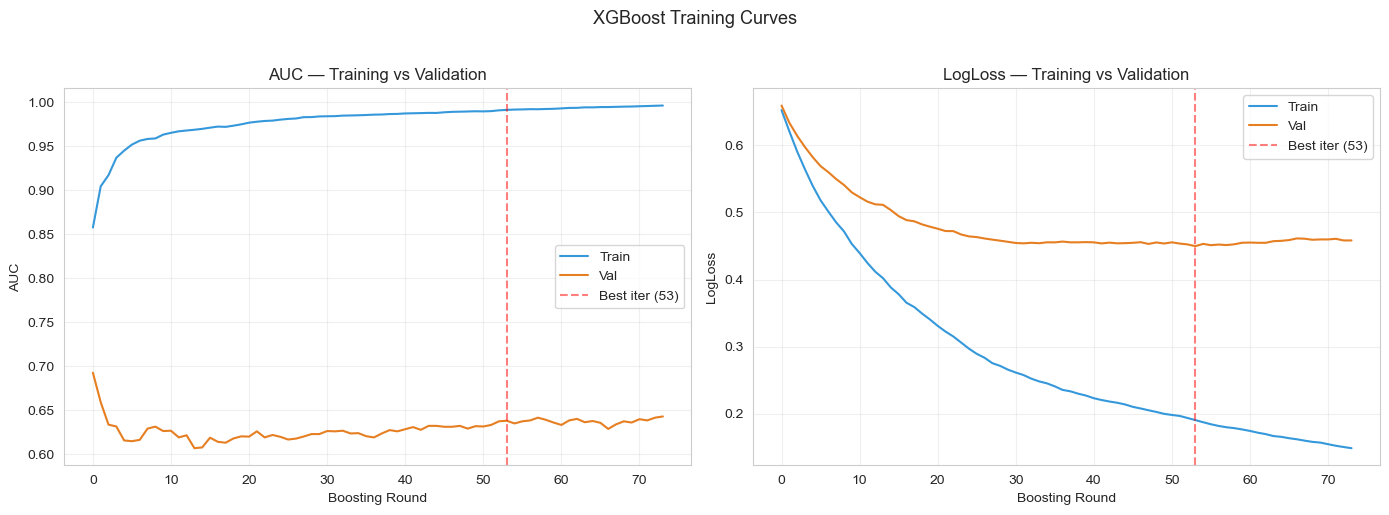

In [8]:
# Training curves — detect overfitting
results = model.evals_result()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# AUC curves
axes[0].plot(results['validation_0']['auc'], label='Train', color='#3498db')
axes[0].plot(results['validation_1']['auc'], label='Val', color='#e67e22')
axes[0].axvline(model.best_iteration, color='red', linestyle='--', alpha=0.5, label=f'Best iter ({model.best_iteration})')
axes[0].set_xlabel('Boosting Round')
axes[0].set_ylabel('AUC')
axes[0].set_title('AUC — Training vs Validation')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# LogLoss curves
axes[1].plot(results['validation_0']['logloss'], label='Train', color='#3498db')
axes[1].plot(results['validation_1']['logloss'], label='Val', color='#e67e22')
axes[1].axvline(model.best_iteration, color='red', linestyle='--', alpha=0.5, label=f'Best iter ({model.best_iteration})')
axes[1].set_xlabel('Boosting Round')
axes[1].set_ylabel('LogLoss')
axes[1].set_title('LogLoss — Training vs Validation')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('XGBoost Training Curves', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


In [9]:
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report

# Evaluate on all three splits
for name, X_split, y_split in [('Train', X_train, y_train), ('Val', X_val, y_val), ('Test', X_test, y_test)]:
    y_prob = model.predict_proba(X_split)[:, 1]
    y_pred = (y_prob > 0.5).astype(int)
    if len(set(y_split)) > 1:
        auc = roc_auc_score(y_split, y_prob)
    else:
        auc = 0
    acc = accuracy_score(y_split, y_pred)
    print(f'{name:>6} | AUC: {auc:.3f} | Acc: {acc:.3f} | n={len(y_split)}')

print(f'\n--- Test set classification report ---')
y_test_prob = model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_prob > 0.5).astype(int)
print(classification_report(y_test, y_test_pred, target_names=['retained', 'churned'], zero_division=0))


 Train | AUC: 0.991 | Acc: 0.954 | n=1166
   Val | AUC: 0.638 | Acc: 0.799 | n=149
  Test | AUC: 0.621 | Acc: 0.826 | n=149

--- Test set classification report ---
              precision    recall  f1-score   support

    retained       0.85      0.97      0.90       126
     churned       0.20      0.04      0.07        23

    accuracy                           0.83       149
   macro avg       0.52      0.51      0.49       149
weighted avg       0.75      0.83      0.78       149



## Sorting Smoothing Method (SSM) — Yeh & Lien (2009)

Calibrate raw XGBoost scores into empirical probabilities.
Tells us if "model says 25% churn" really means "25% of these deals churn."

- Perfect calibration: intercept=0, slope=1, R²=1
- Good enough for production: R² > 0.8

See `context/SSM_REFERENCE.md` for full explanation.

In [10]:
from scipy.stats import linregress

def sorting_smoothing_method(y_true, y_pred, n=25):
    """
    Yeh & Lien (2009) SSM — calibrate predicted probs to empirical probs.
    Returns sorted_pred, smoothed_actual, intercept, slope, r_squared.
    """
    sorted_idx = np.argsort(y_pred)
    sorted_y_true = y_true[sorted_idx]
    sorted_y_pred = y_pred[sorted_idx]

    estimated = np.zeros_like(sorted_y_true, dtype=float)
    for i in range(len(sorted_y_true)):
        lo = max(0, i - n)
        hi = min(len(sorted_y_true), i + n + 1)
        estimated[i] = np.mean(sorted_y_true[lo:hi])

    slope, intercept, r_value, _, _ = linregress(sorted_y_pred, estimated)
    return {
        "sorted_pred": sorted_y_pred,
        "smoothed_actual": estimated,
        "intercept": intercept,
        "slope": slope,
        "r_squared": r_value ** 2,
    }

# Use validation set (not test — test stays held out for final metrics)
y_val_prob = model.predict_proba(X_val)[:, 1]
ssm = sorting_smoothing_method(y_val, y_val_prob, n=15)

print(f"SSM calibration on validation set:")
print(f"  Intercept: {ssm['intercept']:+.3f}  (ideal: 0)")
print(f"  Slope:     {ssm['slope']:+.3f}    (ideal: 1)")
print(f"  R²:        {ssm['r_squared']:.3f}    (ideal: 1)")


SSM calibration on validation set:
  Intercept: +0.098  (ideal: 0)
  Slope:     +0.325    (ideal: 1)
  R²:        0.371    (ideal: 1)


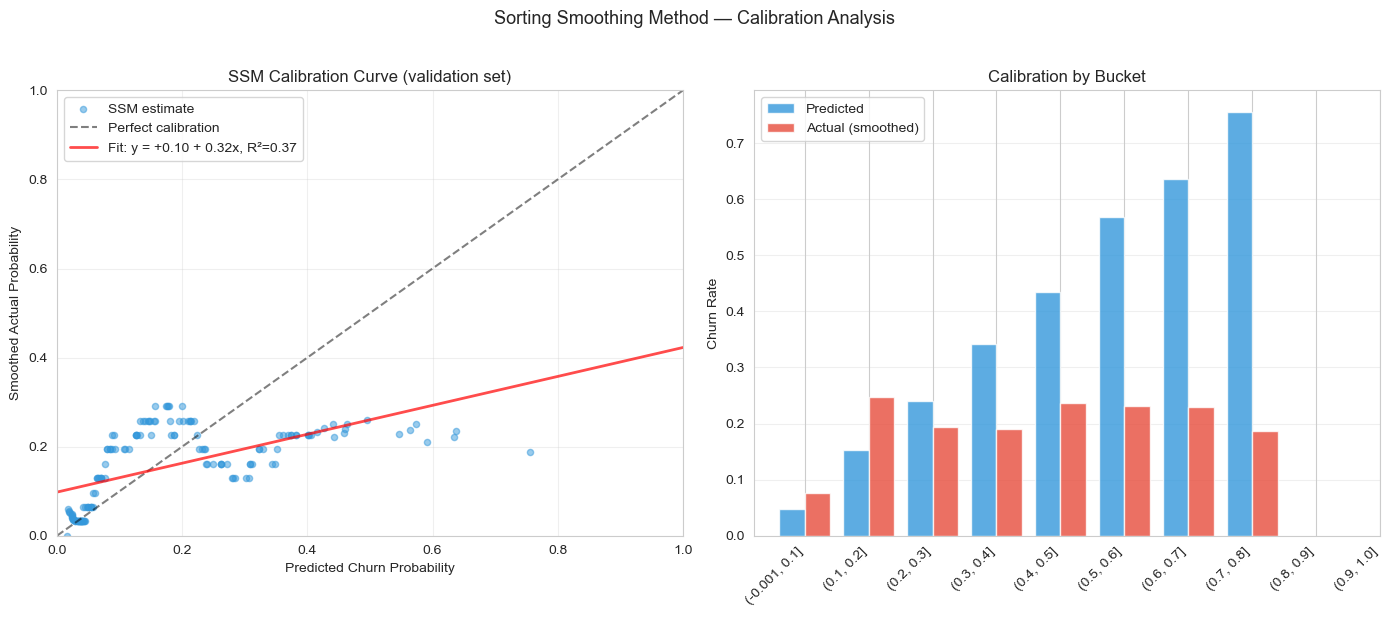


Bucketed calibration:
       bucket  avg_predicted  actual_rate  n
(-0.001, 0.1]       0.047243     0.076826 63
   (0.1, 0.2]       0.152601     0.247696 28
   (0.2, 0.3]       0.240465     0.193548 21
   (0.3, 0.4]       0.341754     0.189964 18
   (0.4, 0.5]       0.434479     0.235983 12
   (0.5, 0.6]       0.568550     0.231474  4
   (0.6, 0.7]       0.635869     0.228758  2
   (0.7, 0.8]       0.756342     0.187500  1
   (0.8, 0.9]            NaN          NaN  0
   (0.9, 1.0]            NaN          NaN  0


In [11]:
# Calibration curve — predicted vs smoothed actual
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: raw SSM calibration curve
axes[0].scatter(ssm["sorted_pred"], ssm["smoothed_actual"], alpha=0.5, s=20, color="#3498db", label="SSM estimate")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5, label="Perfect calibration")
x_line = np.linspace(0, 1, 100)
y_line = ssm["intercept"] + ssm["slope"] * x_line
axes[0].plot(x_line, y_line, "r-", alpha=0.7, linewidth=2,
             label=f"Fit: y = {ssm['intercept']:+.2f} + {ssm['slope']:.2f}x, R²={ssm['r_squared']:.2f}")
axes[0].set_xlabel("Predicted Churn Probability")
axes[0].set_ylabel("Smoothed Actual Probability")
axes[0].set_title("SSM Calibration Curve (validation set)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)

# Right: bucketed calibration table
df_cal = pd.DataFrame({"predicted": ssm["sorted_pred"], "smoothed_actual": ssm["smoothed_actual"]})
df_cal["bucket"] = pd.cut(df_cal["predicted"], bins=np.linspace(0, 1, 11), include_lowest=True)
bucket_stats = df_cal.groupby("bucket", observed=False).agg(
    avg_predicted=("predicted", "mean"),
    actual_rate=("smoothed_actual", "mean"),
    n=("predicted", "count"),
).reset_index()

x_pos = range(len(bucket_stats))
axes[1].bar([i - 0.2 for i in x_pos], bucket_stats["avg_predicted"], width=0.4,
            color="#3498db", label="Predicted", alpha=0.8)
axes[1].bar([i + 0.2 for i in x_pos], bucket_stats["actual_rate"], width=0.4,
            color="#e74c3c", label="Actual (smoothed)", alpha=0.8)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([str(b) for b in bucket_stats["bucket"]], rotation=45, ha="right")
axes[1].set_ylabel("Churn Rate")
axes[1].set_title("Calibration by Bucket")
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis="y")

plt.suptitle("Sorting Smoothing Method — Calibration Analysis", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("\nBucketed calibration:")
print(bucket_stats.to_string(index=False))


In [12]:
# Save calibration buckets + base rate for use at inference
from nodes.risk_calibration import save_calibration

buckets_out = []
for row in bucket_stats.itertuples():
    bucket = row.bucket  # pandas Interval
    n = int(row.n) if not pd.isna(row.n) else 0
    if n == 0:
        buckets_out.append({
            "bucket_low": float(bucket.left),
            "bucket_high": float(bucket.right),
            "avg_predicted": None,
            "actual_rate": None,
            "n": 0,
        })
    else:
        buckets_out.append({
            "bucket_low": float(bucket.left),
            "bucket_high": float(bucket.right),
            "avg_predicted": float(row.avg_predicted),
            "actual_rate": float(row.actual_rate),
            "n": n,
        })

# Base rate from ORIGINAL (non-SMOTE) training data — what we actually observe
base_rate = float(y.mean())  # uses the full dataset before SMOTE

save_calibration(buckets_out, base_rate)
print(f"Saved calibration:")
print(f"  Base rate: {base_rate:.1%}")
print(f"  Buckets: {len(buckets_out)} ({sum(1 for b in buckets_out if b['n'] > 0)} populated)")


Saved calibration:
  Base rate: 15.7%
  Buckets: 10 (8 populated)


## SHAP Explainability

In [13]:
# Build SHAP explainer (uses xgboost 1.7.x format)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train)  # explain on train set

print(f'SHAP values shape: {shap_values.shape}')
print(f'Expected value: {explainer.expected_value}')


SHAP values shape: (1166, 54)
Expected value: -0.0031376562546938658


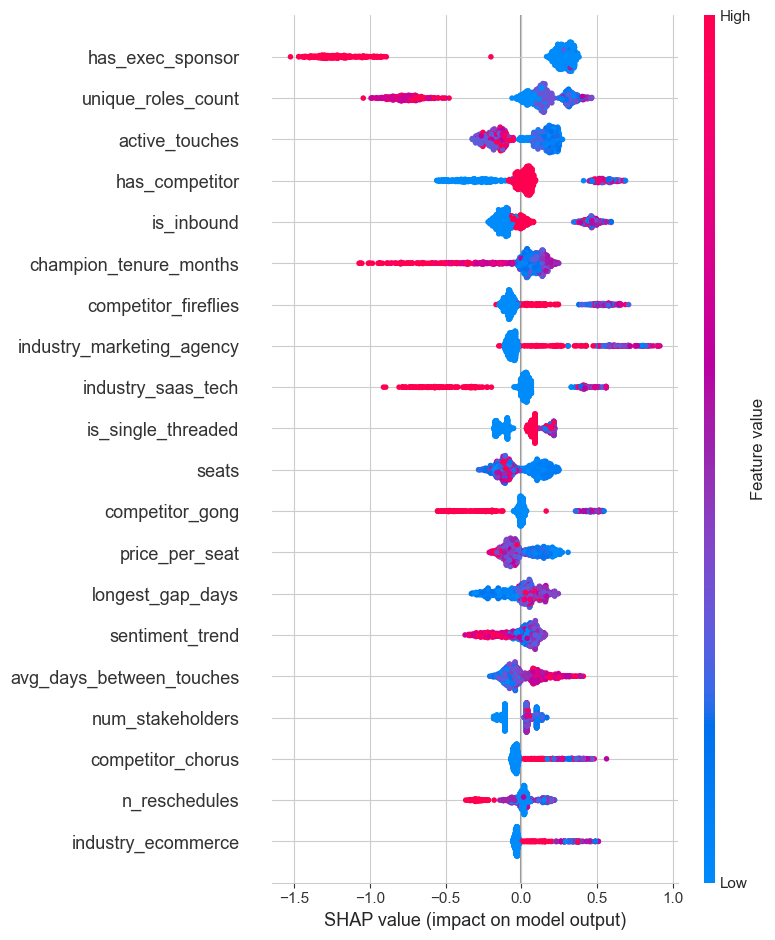

In [14]:
plt.figure(figsize=(10, 10))
shap.summary_plot(shap_values, X_train, feature_names=FEATURE_COLUMNS, show=False, max_display=20)
plt.tight_layout()
plt.show()

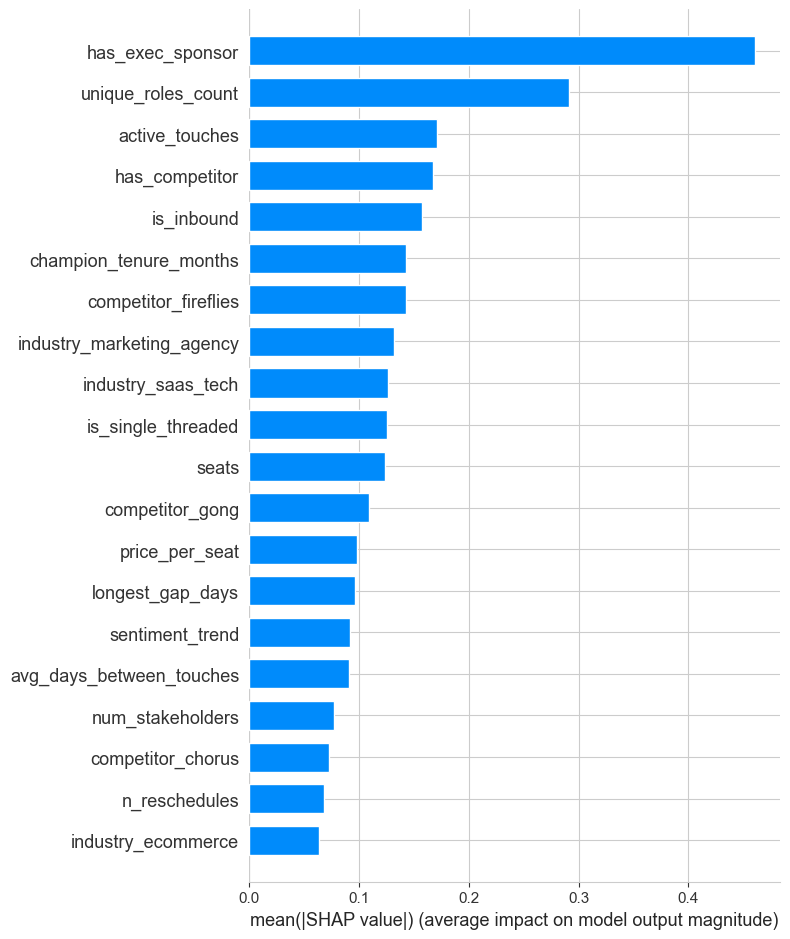

In [15]:
plt.figure(figsize=(10, 10))
shap.summary_plot(shap_values, X_train, feature_names=FEATURE_COLUMNS, plot_type='bar', show=False, max_display=20)
plt.tight_layout()
plt.show()

## Inspect a Single Deal

In [16]:
# Inspect first TEST deal — unseen by model
idx = 0
test_shap = explainer.shap_values(X_test[idx:idx+1])[0]
test_pred = model.predict_proba(X_test[idx:idx+1])[0, 1]

# Find this deal in the original list (tricky since we split by index)
print(f"Test deal #{idx} (from held-out set)")
print(f"Actual: {'churned' if y_test[idx] == 1 else 'retained'}")
print(f"Predicted churn: {test_pred:.3f}")

shap_for_deal = dict(zip(FEATURE_COLUMNS, test_shap))
sorted_shap = sorted(shap_for_deal.items(), key=lambda x: abs(x[1]), reverse=True)[:10]

print(f'\nTop features driving this prediction:')
for name, val in sorted_shap:
    direction = '↑ risk' if val > 0 else '↓ risk'
    print(f'  {direction}  {name}: {val:+.4f}')


Test deal #0 (from held-out set)
Actual: retained
Predicted churn: 0.054

Top features driving this prediction:
  ↓ risk  has_exec_sponsor: -1.2862
  ↓ risk  unique_roles_count: -0.6981
  ↓ risk  champion_tenure_months: -0.2644
  ↑ risk  industry_vertical_saas: +0.1380
  ↓ risk  price_per_seat: -0.1181
  ↓ risk  active_touches: -0.1145
  ↓ risk  avg_days_between_touches: -0.1011
  ↓ risk  product_tier_encoded: -0.0906
  ↓ risk  is_inbound: -0.0893
  ↓ risk  industry_marketing_agency: -0.0824


## Save Model + SHAP Explainer

In [17]:
import os
import pickle

MODELS_DIR = '../backend/data/models/xgb'
os.makedirs(MODELS_DIR, exist_ok=True)

with open(f'{MODELS_DIR}/model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open(f'{MODELS_DIR}/shap_explainer.pkl', 'wb') as f:
    pickle.dump(explainer, f)

print(f'Saved to {MODELS_DIR}/')

Saved to ../backend/data/models/xgb/
